## Notebook for identifying TF communities n the Joung2023 dataset

In [1]:
# set up
import math
import pickle
import os
import requests

import anndata
import gseapy as gp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from gseapy.parser import DEFAULT_CACHE_PATH
from scipy.stats import false_discovery_control, norm
from sklearn.mixture import GaussianMixture

from gcrl.grn import (
    build_cluster_gene_sets,
    build_coassociation_matrix,
    build_tf_tf_cotarget_layer,
    build_tf_tf_regulatory_layer,
    community_stats,
    compute_go_levels,
    consensus_partition_from_coassoc,
    extract_go_ids_from_terms,
    filter_cluster_specific_terms,
    filter_gene_sets_by_size_and_level,
    filter_trivial_partitions,
    partition_stability_diagnostics,
    plot_enrichment_dotplot,
    plot_tf_tf_communities,
    prettify_go_term,
    run_ora_for_clusters,
    run_single_layer_leiden_cot,
    run_single_layer_leiden_reg,
)

In [2]:
# Control parameters
data_folder       = '../../../data/real/Joung2023_random_subsample/'   # path to data folder
results_folder    = '../../../data/real/Joung2023_random_subsample/GRN/'  # path to results folder
figures_folder    = results_folder + 'figures/'        # output folder for saved plots
significance_level = 0.05   # FDR threshold for GRN edge filtering
min_size          = 5       # minimum cluster size (smaller clusters are merged)
top_percentage    = 0.5     # fraction of top-ranked edges to retain

# 3. Hyperparameter grids (tune as needed)
# NOTE: Using ONLY g_reg (regulatory layer), NO cotarget layer
# gamma_reg_list = [1.0, 1.1, 1.2, 1.25, 1.3, 1.4, 1.5] # 1.4
# gamma_reg_list = [0.9, 1.0, 1.1] # 1.0
# gamma_reg_list = [0.9] # 0.9
# gamma_reg_list = [1.5, 1.6, 1.7, 1.8, 1.9, 2.0, 2.1, 2.2, 2.3, 2.4, 2.5] # 2.5
gamma_reg_list = list(np.round(np.arange(0.8, 2.1, 0.1), 1))
n_seeds = 100

# HVG universe for ORA: the 5,000 most variable genes used to build the GRN.
# Loaded once here so it is available throughout the notebook.
adata     = anndata.read_h5ad(data_folder + 'Joung2023.h5ad')
hvg_names = list(adata.var_names)  # all 5,000 HVGs
del adata  # free memory; only the gene names are needed

# Helper: save a figure as PNG and SVG, then display it
os.makedirs(figures_folder, exist_ok=True)

def save_figure(fig, name):
    """Save fig to figures_folder as <name>.png and <name>.svg, then show."""
    fig.savefig(figures_folder + name + '.png', dpi=150, bbox_inches='tight')
    fig.savefig(figures_folder + name + '.svg', bbox_inches='tight')
    plt.show()
    print(f'Saved: {figures_folder}{name}.png / .svg')


### Loading and filtering GRN

In [3]:
#Load GRN 
raw_grn = pd.read_csv(results_folder + "raw_GRN.csv", index_col=0)

#Drop NA values in p-value column
raw_grn = raw_grn.dropna(subset=["p"])

#FDR filtering and only leaving adj p-values values less than 0.05
raw_grn.loc[:, 'adjp'] = false_discovery_control(raw_grn['p'].values, method='bh')
filtered_grn = raw_grn[raw_grn['adjp'] <= significance_level].copy()

# Sort by absolute coefficient descending
filtered_grn = filtered_grn.sort_values(by='coef_abs', ascending=False).reset_index(drop=True)


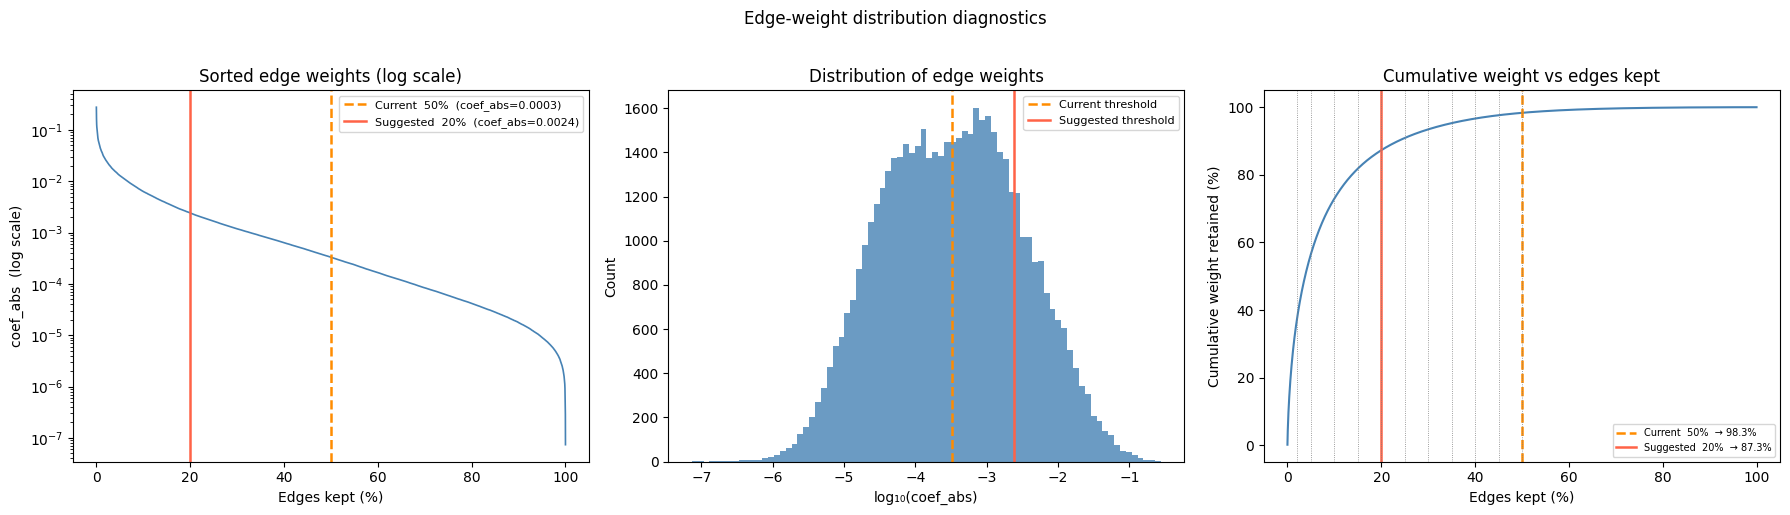

Saved: ../../../data/real/Joung2023_random_subsample/GRN/figures/edge_weight_diagnostics.png / .svg
   Threshold   N edges    coef_abs ≥   Cumul. weight    Δ weight
--------------------------------------------------------------------
          2%      1027        0.0258           37.0%           —
          5%      2569        0.0129           56.5%      +19.5%
         10%      5138        0.0063           73.0%      +16.4%
         15%      7708        0.0038           81.8%       +8.9%
         20%     10277        0.0024           87.3%       +5.4%  ← suggested
         25%     12847        0.0017           90.9%       +3.6%
         30%     15416        0.0012           93.4%       +2.6%
         35%     17985        0.0009           95.3%       +1.8%
         40%     20555        0.0006           96.6%       +1.4%
         45%     23124        0.0005           97.6%       +1.0%
         50%     25694        0.0003           98.3%       +0.7%

Suggested top_percentage = 0.2  (firs

In [4]:
# Edge-weight threshold diagnostics
# -----------------------------------
# GRN edge-weight distributions are typically heavy-tailed: the diagonal-distance
# elbow on the raw curve always snaps to the very first steep drop and is not useful.
# Instead we show three complementary views to help choose top_percentage:
#
#   1. Log-scale sorted weights  – reveals natural breaks / slope changes in the tail
#   2. Histogram of log10(coef_abs) – shows the shape of the distribution
#   3. Cumulative % of total weight retained vs edges kept – balances coverage vs sparsity

weights_sorted = filtered_grn['coef_abs'].values   # already sorted descending
n = len(weights_sorted)
pct_axis = np.linspace(0, 100, n)
cum_weight = np.cumsum(weights_sorted) / weights_sorted.sum() * 100

# Candidate thresholds and their cumulative weight
candidates = [0.02, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]
cw_vals = [cum_weight[int(p * n) - 1] for p in candidates]

# Find the first candidate where the cumulative weight gain over the previous step < 5%
suggested_pct = candidates[-1]
for i in range(1, len(candidates)):
    if cw_vals[i] - cw_vals[i - 1] < 5.0:
        suggested_pct = candidates[i - 1]
        break

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- 1. Log-scale sorted weights ---
axes[0].semilogy(pct_axis, weights_sorted, color='steelblue', lw=1.2)
axes[0].axvline(top_percentage * 100, color='darkorange', lw=1.8, linestyle='--',
                label=f'Current  {top_percentage*100:.0f}%'
                      f'  (coef_abs={weights_sorted[int(top_percentage*n)-1]:.4f})')
axes[0].axvline(suggested_pct * 100, color='tomato', lw=1.8, linestyle='-',
                label=f'Suggested  {suggested_pct*100:.0f}%'
                      f'  (coef_abs={weights_sorted[int(suggested_pct*n)-1]:.4f})')
axes[0].set_xlabel('Edges kept (%)')
axes[0].set_ylabel('coef_abs  (log scale)')
axes[0].set_title('Sorted edge weights (log scale)')
axes[0].legend(fontsize=8)

# --- 2. Histogram of log10(coef_abs) ---
log_w = np.log10(weights_sorted[weights_sorted > 0])
axes[1].hist(log_w, bins=80, color='steelblue', edgecolor='none', alpha=0.8)
axes[1].axvline(np.log10(weights_sorted[int(top_percentage * n) - 1]),
                color='darkorange', lw=1.8, linestyle='--', label='Current threshold')
axes[1].axvline(np.log10(weights_sorted[int(suggested_pct * n) - 1]),
                color='tomato', lw=1.8, linestyle='-', label='Suggested threshold')
axes[1].set_xlabel('log₁₀(coef_abs)')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of edge weights')
axes[1].legend(fontsize=8)

# --- 3. Cumulative weight with gain bars ---
axes[2].plot(pct_axis, cum_weight, color='steelblue', lw=1.5)
axes[2].axvline(top_percentage * 100, color='darkorange', lw=1.8, linestyle='--',
                label=f'Current  {top_percentage*100:.0f}%  → {cum_weight[int(top_percentage*n)-1]:.1f}%')
axes[2].axvline(suggested_pct * 100, color='tomato', lw=1.8, linestyle='-',
                label=f'Suggested  {suggested_pct*100:.0f}%  → {cum_weight[int(suggested_pct*n)-1]:.1f}%')
for pct in candidates:
    idx = int(pct * n) - 1
    axes[2].axvline(pct * 100, color='gray', lw=0.6, linestyle=':')
axes[2].set_xlabel('Edges kept (%)')
axes[2].set_ylabel('Cumulative weight retained (%)')
axes[2].set_title('Cumulative weight vs edges kept')
axes[2].legend(fontsize=7)

plt.suptitle('Edge-weight distribution diagnostics', y=1.02)
plt.tight_layout()
save_figure(fig, 'edge_weight_diagnostics')

# Summary table
print(f"{'Threshold':>12}  {'N edges':>8}  {'coef_abs ≥':>12}  {'Cumul. weight':>14}  {'Δ weight':>10}")
print("-" * 68)
for i, pct in enumerate(candidates):
    idx = max(0, int(pct * n) - 1)
    delta = f"{cw_vals[i] - cw_vals[i-1]:+.1f}%" if i > 0 else "    —"
    marker = "  ← suggested" if pct == suggested_pct else ""
    print(f"{pct*100:>11.0f}%  {idx+1:>8d}  {weights_sorted[idx]:>12.4f}  "
          f"{cw_vals[i]:>13.1f}%  {delta:>10}{marker}")

print(f"\nSuggested top_percentage = {suggested_pct}"
      f"  (first step where Δ cumulative weight < 5%)")

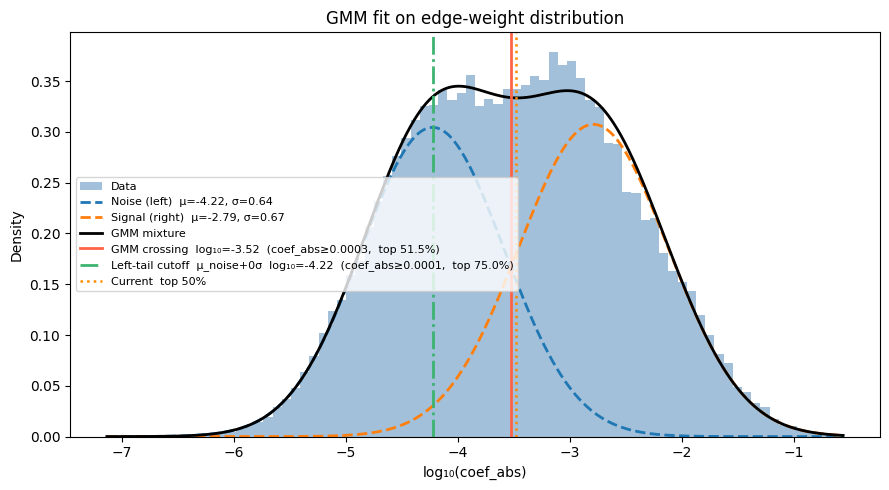

Saved: ../../../data/real/Joung2023_random_subsample/GRN/figures/gmm_threshold.png / .svg
GMM crossing      → coef_abs ≥ 0.0003  (top 51.5%,  26450 edges)
Left-tail cutoff  → coef_abs ≥ 0.0001  (top 75.0%,  38518 edges)  [noise μ - 0σ = -4.22 - 0×0.64]
Current setting   → coef_abs ≥ 0.0003  (top 50%,  25694 edges)


In [5]:
# GMM threshold: fit 2 Gaussians on log10(coef_abs), find the crossing point
# ---------------------------------------------------------------------------
# Two thresholds are computed:
#   1. GMM crossing  : where signal PDF overtakes noise PDF (between the two means).
#      Keeps only edges that are more likely signal than noise.
#   2. Left-tail cutoff: mean of the noise Gaussian + n_sigma * std.
#      Removes only the very weakest edges (deep left tail of the noise component).
#      More permissive than the crossing — useful as a soft floor before ORA.

n_sigma_tail = 0  # how many std above the noise mean to set the left-tail cutoff

log_w = np.log10(weights_sorted[weights_sorted > 0])

# Fit 2-component GMM
gmm = GaussianMixture(n_components=2, random_state=42)
gmm.fit(log_w.reshape(-1, 1))

# Sort components by mean so component 0 = noise (left), 1 = signal (right)
order = np.argsort(gmm.means_.ravel())
means  = gmm.means_.ravel()[order]
stds   = np.sqrt(gmm.covariances_.ravel())[order]
weights_gmm = gmm.weights_[order]

# --- Threshold 1: crossing point between the two weighted Gaussians ---
# Solve: w0 * N(x; mu0, s0) = w1 * N(x; mu1, s1)  on a fine grid
x_grid = np.linspace(log_w.min(), log_w.max(), 10_000)
pdf0 = weights_gmm[0] * norm.pdf(x_grid, means[0], stds[0])
pdf1 = weights_gmm[1] * norm.pdf(x_grid, means[1], stds[1])

# Crossing between the two means = the valley
between = (x_grid > means[0]) & (x_grid < means[1])
diff = pdf1[between] - pdf0[between]
sign_changes = np.where(np.diff(np.sign(diff)))[0]
if len(sign_changes) > 0:
    cross_log = x_grid[between][sign_changes[0]]
else:
    cross_log = x_grid[between][np.argmin(pdf0[between] + pdf1[between])]

cross_coef = 10 ** cross_log
gmm_pct = np.mean(weights_sorted >= cross_coef)
gmm_n   = int(gmm_pct * n)

# --- Threshold 2: left-tail cutoff (noise mean + n_sigma * noise std) ---
# This excludes only the deepest left tail of the noise component.
tail_log  = means[0] - n_sigma_tail * stds[0]
tail_coef = 10 ** tail_log
tail_pct  = np.mean(weights_sorted >= tail_coef)
tail_n    = int(tail_pct * n)

# --- Plot ---
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(log_w, bins=80, density=True, color='steelblue', alpha=0.5,
        edgecolor='none', label='Data')

x_plot = np.linspace(log_w.min(), log_w.max(), 1000)
for i, (m, s, w, lbl) in enumerate(zip(means, stds, weights_gmm,
                                        ['Noise (left)', 'Signal (right)'])):
    ax.plot(x_plot, w * norm.pdf(x_plot, m, s),
            lw=2, linestyle='--', label=f'{lbl}  μ={m:.2f}, σ={s:.2f}')

ax.plot(x_plot, (weights_gmm[0] * norm.pdf(x_plot, means[0], stds[0]) +
                 weights_gmm[1] * norm.pdf(x_plot, means[1], stds[1])),
        lw=2, color='black', label='GMM mixture')

ax.axvline(cross_log, color='tomato', lw=2, linestyle='-',
           label=f'GMM crossing  log₁₀={cross_log:.2f}'
                 f'  (coef_abs≥{cross_coef:.4f},  top {gmm_pct*100:.1f}%)')
ax.axvline(tail_log, color='mediumseagreen', lw=2, linestyle='-.',
           label=f'Left-tail cutoff  μ_noise+{n_sigma_tail}σ  log₁₀={tail_log:.2f}'
                 f'  (coef_abs≥{tail_coef:.4f},  top {tail_pct*100:.1f}%)')
ax.axvline(np.log10(weights_sorted[int(top_percentage * n) - 1]),
           color='darkorange', lw=1.8, linestyle=':',
           label=f'Current  top {top_percentage*100:.0f}%')

ax.set_xlabel('log₁₀(coef_abs)')
ax.set_ylabel('Density')
ax.set_title('GMM fit on edge-weight distribution')
ax.legend(fontsize=8)
plt.tight_layout()
save_figure(fig, 'gmm_threshold')

print(f"GMM crossing      → coef_abs ≥ {cross_coef:.4f}  "
      f"(top {gmm_pct*100:.1f}%,  {gmm_n} edges)")
print(f"Left-tail cutoff  → coef_abs ≥ {tail_coef:.4f}  "
      f"(top {tail_pct*100:.1f}%,  {tail_n} edges)  "
      f"[noise μ - {n_sigma_tail}σ = {means[0]:.2f} - {n_sigma_tail}×{stds[0]:.2f}]")
print(f"Current setting   → coef_abs ≥ {weights_sorted[int(top_percentage*n)-1]:.4f}  "
      f"(top {top_percentage*100:.0f}%,  {int(top_percentage*n)} edges)")


In [6]:
# selecting top_percentage of top edges
num_top_edges = math.ceil(len(filtered_grn) * top_percentage)
current_grn = filtered_grn.iloc[:num_top_edges, :]

# print statistics
print(current_grn['source'].nunique(), current_grn['target'].nunique())
current_grn

150 1646


,source,target,coef_mean,coef_abs,p,-logp,adjp
0,RORA,HIST1H4C,0.277339,0.277339,4.693664e-14,13.328488,4.250968e-13
1,KLF12,GRID2,0.247255,0.247255,1.108654e-20,19.955204,3.634006e-18
2,RORA,MALAT1,0.236262,0.236262,9.799930e-20,19.008777,1.722947e-17
3,NRF1,HIST1H4I,0.231370,0.231370,3.605119e-21,20.443080,1.763983e-18
4,NRF1,HIST1H1E,0.222723,0.222723,2.236666e-15,14.650399,3.525315e-14
...,...,...,...,...,...,...,...
25689,NR3C2,HOXB3,0.000331,0.000331,1.889549e-11,10.723642,7.422837e-11
25690,FOXS1,LMO3,-0.000331,0.000331,2.799121e-13,12.552978,1.894091e-12
25691,ZEB1,ASPG,0.000331,0.000331,3.786780e-17,16.421730,1.442006e-15
25692,SP7,LINC00624,0.000331,0.000331,1.253820e-11,10.901765,5.163185e-11


In [7]:
# Coverage diagnostics: how much of the original GRN survives thresholding?
# -------------------------------------------------------------------------
_before = filtered_grn
_after  = current_grn

n_edges_before   = len(_before)
n_edges_after    = len(_after)
n_tf_src_before  = _before['source'].nunique()
n_tf_src_after   = _after['source'].nunique()
n_target_before  = _before['target'].nunique()
n_target_after   = _after['target'].nunique()
n_unique_genes_before = pd.concat([_before['source'], _before['target']]).nunique()
n_unique_genes_after  = pd.concat([_after['source'],  _after['target']]).nunique()

print(f"{'Metric':<35} {'Before':>10} {'After':>10} {'Retained':>10}")
print("-" * 67)
print(f"{'Edges':<35} {n_edges_before:>10,} {n_edges_after:>10,} {n_edges_after/n_edges_before:>9.1%}")
print(f"{'TF sources':<35} {n_tf_src_before:>10,} {n_tf_src_after:>10,} {n_tf_src_after/n_tf_src_before:>9.1%}")
print(f"{'Target genes':<35} {n_target_before:>10,} {n_target_after:>10,} {n_target_after/n_target_before:>9.1%}")
print(f"{'Unique genes (src + tgt)':<35} {n_unique_genes_before:>10,} {n_unique_genes_after:>10,} {n_unique_genes_after/n_unique_genes_before:>9.1%}")
print()
print(f"top_percentage = {top_percentage}  →  keeping {n_edges_after:,} / {n_edges_before:,} edges")
print(f"Target gene coverage: {n_target_after:,} / {n_target_before:,}  "
      f"({'good' if n_target_after/n_target_before > 0.6 else 'WARNING: low — consider raising top_percentage'})")


Metric                                  Before      After   Retained
-------------------------------------------------------------------
Edges                                   51,388     25,694     50.0%
TF sources                                 150        150    100.0%
Target genes                             2,409      1,646     68.3%
Unique genes (src + tgt)                 2,411      1,688     70.0%

top_percentage = 0.5  →  keeping 25,694 / 51,388 edges
Target gene coverage: 1,646 / 2,409  (good)


In [8]:
# Save all genes present in the thresholded GRN (sources + targets)
all_genes = sorted(
    set(current_grn['source']).union(current_grn['target'])
)
_top_pct = int(top_percentage * 100)
fname_all_genes = f'all_genes_{_top_pct}pct.txt'
with open(results_folder + fname_all_genes, 'w') as f:
    f.write('\n'.join(all_genes))
print(f'Saved {len(all_genes):,} genes → {results_folder}{fname_all_genes}')

Saved 1,688 genes → ../../../data/real/Joung2023_random_subsample/GRN/all_genes_50pct.txt


### Retrieving the list of TFs

In [9]:
# Load TF reference
tf_info = pd.read_parquet(results_folder + "hg38_TFinfo_dataframe_gimmemotifsv5_fpr2_threshold_10_20210630.parquet")
tf_names = list(tf_info.columns.unique())
tf_names = [item for item in tf_names if item in current_grn['source'].unique() or item in current_grn['target'].unique()]
print(f"Number of TFs in reference: {len(tf_names)}")

Number of TFs in reference: 150


### Initial assessment

In [10]:
# 1. Build layers
g_reg, tf_index = build_tf_tf_regulatory_layer(current_grn, tf_names)
g_cot, sim_matrix = build_tf_tf_cotarget_layer(current_grn, tf_names, tf_index, min_similarity=0.15)
print('Number of edges in g_reg: ', g_reg.ecount())
print('Number of edges in g_cot: ', g_cot.ecount())

# 2. computing memberships
average_gamma = np.array(gamma_reg_list).mean()
mem_reg, _, _ = run_single_layer_leiden_reg(g_reg, gamma_reg=average_gamma, seed=0)
mem_cot, _, _ = run_single_layer_leiden_cot(g_cot, gamma_cot=average_gamma, seed=0)

# 3. computing community statistics
print('Average gamma: ', average_gamma.astype(str))
print(community_stats(g_reg, mem_reg).head(n=10))
print(community_stats(g_reg, mem_reg).shape)
print(community_stats(g_cot, mem_cot).head(n=10))
print(community_stats(g_cot, mem_cot).shape)


Number of edges in g_reg:  1550
Number of edges in g_cot:  2409
Average gamma:  1.4
   community  size  w_internal   density
0          0    32    0.305608  0.000616
1          1    25    0.126431  0.000421
7          2    17    0.241488  0.001776
6          4    16    0.232893  0.001941
2          3    16    0.358828  0.002990
4          5    13    0.224735  0.002881
5          6    11    0.088803  0.001615
3          7    10    0.229441  0.005099
8          8     6    0.062409  0.004161
9          9     1    0.000000  0.000000
(13, 4)
   community  size  w_internal   density
1          0    24   29.957817  0.108543
9          1    19   31.904918  0.186578
5          2    19   35.301449  0.206441
6          3    14   20.420005  0.224396
7          4    14   34.049916  0.374175
4          5    13   10.669130  0.136784
2          6    12   13.858730  0.209981
3          7    11   15.002537  0.272773
0          8    10   12.228907  0.271753
8          9     7    2.870727  0.136701
(13, 4

In [11]:
# 3. Sweep & collect partitions using single-layer clustering on g_reg only
results = {}
for gamma_reg in gamma_reg_list:
    key = gamma_reg
    memberships = []
    for seed in range(n_seeds):
        mem, _, _ = run_single_layer_leiden_reg(g_reg, gamma_reg=gamma_reg, seed=seed)
        memberships.append(mem)
    results[key] = memberships
    print(f'Done γ_reg={gamma_reg}')


Done γ_reg=0.8
Done γ_reg=0.9
Done γ_reg=1.0
Done γ_reg=1.1
Done γ_reg=1.2
Done γ_reg=1.3
Done γ_reg=1.4
Done γ_reg=1.5
Done γ_reg=1.6
Done γ_reg=1.7
Done γ_reg=1.8
Done γ_reg=1.9
Done γ_reg=2.0


In [12]:
# 4. Filter trivial partitions for each hyperparameter combination
filtered_results = {}
for key, memberships in results.items():
    filtered, n_removed = filter_trivial_partitions(
        memberships,
        min_clusters=3,          # At least 3 clusters
        max_cluster_ratio=0.5,   # No more than 50% of nodes as separate clusters
        min_mean_size=3.0,       # Average cluster size >= 3 TFs
        verbose=True
    )
    filtered_results[key] = filtered
    print(f"{key}: kept {len(filtered)}/{len(memberships)} partitions (removed {n_removed})")

# 5. Compute stability on filtered results
stability = {}
for key, membs in filtered_results.items():
    if len(membs) < 2:
        print(f"Skipping {key}: too few valid partitions after filtering")
        continue

    summary, aris, vis = partition_stability_diagnostics(
        membs,
        compute_ari=True,
        max_pairs=200
    )
    stability[key] = summary
    print(f"{key}: VI_mean={summary['VI_mean']:.3f}, ARI_mean={summary['ARI_mean']:.3f}")


Removed 0 trivial partitions out of 100 (0.0%)
0.8: kept 100/100 partitions (removed 0)
Removed 0 trivial partitions out of 100 (0.0%)
0.9: kept 100/100 partitions (removed 0)
Removed 0 trivial partitions out of 100 (0.0%)
1.0: kept 100/100 partitions (removed 0)
Removed 0 trivial partitions out of 100 (0.0%)
1.1: kept 100/100 partitions (removed 0)
Removed 0 trivial partitions out of 100 (0.0%)
1.2: kept 100/100 partitions (removed 0)
Removed 0 trivial partitions out of 100 (0.0%)
1.3: kept 100/100 partitions (removed 0)
Removed 0 trivial partitions out of 100 (0.0%)
1.4: kept 100/100 partitions (removed 0)
Removed 0 trivial partitions out of 100 (0.0%)
1.5: kept 100/100 partitions (removed 0)
Removed 0 trivial partitions out of 100 (0.0%)
1.6: kept 100/100 partitions (removed 0)
Removed 0 trivial partitions out of 100 (0.0%)
1.7: kept 100/100 partitions (removed 0)
Removed 0 trivial partitions out of 100 (0.0%)
1.8: kept 100/100 partitions (removed 0)
Removed 0 trivial partitions out

In [13]:
# saving results and stability summaries for later analysis
# (saved before best_key is known, so filename encodes only top_pct)
_top_pct = int(top_percentage * 100)
with open(results_folder + f'filtered_results_{_top_pct}pct.pkl', 'wb') as f:
    pickle.dump(filtered_results, f)
with open(results_folder + f'stability_{_top_pct}pct.pkl', 'wb') as f:
    pickle.dump(stability, f)
#with open(results_folder + f'filtered_results_{_top_pct}pct.pkl', 'rb') as f:
#    filtered_results = pickle.load(f)
#with open(results_folder + f'stability_{_top_pct}pct.pkl', 'rb') as f:
#    stability = pickle.load(f)

/tmp/ipykernel_2952038/2671634353.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend(fontsize=8)
/tmp/ipykernel_2952038/2671634353.py:32: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend(fontsize=8)
/tmp/ipykernel_2952038/2671634353.py:39: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[2].legend(fontsize=8)
/tmp/ipykernel_2952038/2671634353.py:47: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[3].legend(fontsize=8)


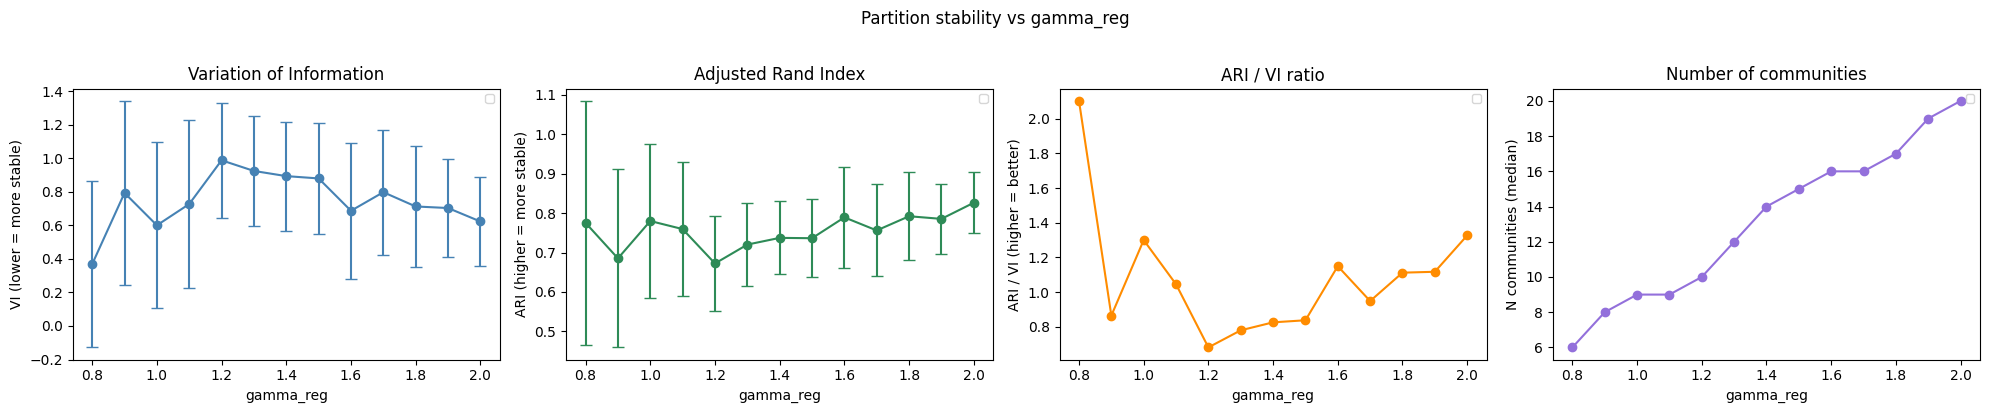

Saved: ../../../data/real/Joung2023_random_subsample/GRN/figures/stability_vs_gamma.png / .svg
   gamma    VI_mean    VI_std    ARI_mean    ARI_std    ARI/VI   n_comm
------------------------------------------------------------------------
     0.8      0.369     0.496       0.775      0.309     2.103        6
     0.9      0.793     0.548       0.685      0.226     0.864        8
     1.0      0.600     0.495       0.780      0.196     1.300        9
     1.1      0.727     0.498       0.759      0.170     1.045        9
     1.2      0.987     0.344       0.672      0.120     0.681       10
     1.3      0.924     0.329       0.720      0.104     0.779       12
     1.4      0.893     0.325       0.737      0.092     0.825       14
     1.5      0.879     0.329       0.736      0.099     0.837       15
     1.6      0.687     0.406       0.789      0.128     1.150       16
     1.7      0.797     0.373       0.756      0.117     0.948       16
     1.8      0.712     0.362       0.79

In [14]:
# Stability diagnostics: VI, ARI, ARI/VI, and n_communities vs gamma_reg
# -----------------------------------------------------------------------
# VI decreases and ARI increases as gamma grows — if both move monotonically
# all the way to the grid edge, the best gamma is just the coarsest partition,
# not a genuinely stable one. Look for an elbow where improvement slows down.
# n_communities is the median number of communities across seeds (after filtering).

gammas    = sorted(stability.keys())
vi_means  = [stability[g]['VI_mean']  for g in gammas]
vi_stds   = [stability[g]['VI_std']   for g in gammas]
ari_means = [stability[g]['ARI_mean'] for g in gammas]
ari_stds  = [stability[g]['ARI_std']  for g in gammas]
ratio     = [a / v if v > 0 else float('nan') for a, v in zip(ari_means, vi_means)]
n_comms   = [int(np.median([len(set(m)) for m in filtered_results[g]])) for g in gammas]

fig, axes = plt.subplots(1, 4, figsize=(20, 4))

# --- VI ---
axes[0].errorbar(gammas, vi_means, yerr=vi_stds,
                 marker='o', color='steelblue', capsize=4, lw=1.5)
axes[0].set_xlabel('gamma_reg')
axes[0].set_ylabel('VI (lower = more stable)')
axes[0].set_title('Variation of Information')
axes[0].legend(fontsize=8)

# --- ARI ---
axes[1].errorbar(gammas, ari_means, yerr=ari_stds,
                 marker='o', color='seagreen', capsize=4, lw=1.5)
axes[1].set_xlabel('gamma_reg')
axes[1].set_ylabel('ARI (higher = more stable)')
axes[1].set_title('Adjusted Rand Index')
axes[1].legend(fontsize=8)

# --- ARI / VI ---
axes[2].plot(gammas, ratio, marker='o', color='darkorange', lw=1.5)
axes[2].set_xlabel('gamma_reg')
axes[2].set_ylabel('ARI / VI (higher = better)')
axes[2].set_title('ARI / VI ratio')
axes[2].legend(fontsize=8)

# --- n_communities ---
axes[3].plot(gammas, n_comms, marker='o', color='mediumpurple', lw=1.5)
axes[3].set_xlabel('gamma_reg')
axes[3].set_ylabel('N communities (median)')
axes[3].set_title('Number of communities')
axes[3].yaxis.set_major_locator(plt.MaxNLocator(integer=True))
axes[3].legend(fontsize=8)

plt.suptitle('Partition stability vs gamma_reg', y=1.02)
plt.tight_layout()
save_figure(fig, 'stability_vs_gamma')

# Summary table
print(f"{'gamma':>8}  {'VI_mean':>9}  {'VI_std':>8}  {'ARI_mean':>10}  {'ARI_std':>9}  {'ARI/VI':>8}  {'n_comm':>7}")
print('-' * 72)
for g, vm, vs, am, as_, r, nc in zip(gammas, vi_means, vi_stds, ari_means, ari_stds, ratio, n_comms):
    marker = ''
    r_str = f'{r:>8.3f}' if not (r != r) else '     nan'  # handle nan
    print(f"{g:>8.1f}  {vm:>9.3f}  {vs:>8.3f}  {am:>10.3f}  {as_:>9.3f}  {r_str}  {nc:>7d}{marker}")


In [27]:
# Pick the most stable gamma_reg (lowest VI_mean)
best_key = 1.6#min(stability.items(), key=lambda kv: kv[1]['VI_mean'])[0]
print("Best hyperparams (gamma_reg):", best_key)
print("Best stability stats:", stability[best_key])

# 6. Consensus clustering for best hyperparams
memberships_list = filtered_results[best_key]
C = build_coassociation_matrix(memberships_list)
consensus_labels, consensus_graph = consensus_partition_from_coassoc(
    C, min_coassoc=0.5, resolution=1.5
)

# 7. Diagnostics for g_reg layer only
df_reg_stats = community_stats(g_reg, consensus_labels)

print("Regulatory layer community stats:")
print(df_reg_stats)


Best hyperparams (gamma_reg): 1.6
Best stability stats: {'VI_mean': np.float64(0.6865416833745499), 'VI_std': np.float64(0.40637676532091427), 'ARI_mean': np.float64(0.7892041351407875), 'ARI_std': np.float64(0.12816652288327116), 'n_pairs': 200}
Regulatory layer community stats:
    community  size  w_internal   density
1           0    24    0.194928  0.000706
4           1    21    0.120422  0.000573
9           2    13    0.221371  0.002838
8           3    12    0.149236  0.002261
6           5    11    0.189819  0.003451
0           4    11    0.067281  0.001223
3           8    10    0.231043  0.005134
2           6    10    0.094292  0.002095
7           7    10    0.087453  0.001943
5           9     9    0.023393  0.000650
11         10     9    0.162639  0.004518
10         11     6    0.062409  0.004161
12         12     1    0.000000  0.000000
13         13     1    0.000000  0.000000
14         14     1    0.000000  0.000000
15         15     1    0.000000  0.000000


In [28]:
# Count elements per cluster
counts = pd.DataFrame({"consensus_labels": consensus_labels})["consensus_labels"].value_counts().to_dict()

# Identify small clusters
small_clusters = {lab for lab, cnt in counts.items() if cnt < min_size}

# Replace small clusters with the minimum label
min_label = int(np.min(np.array(list(small_clusters))))
consensus_labels = np.where(np.isin(consensus_labels, list(small_clusters)), min_label, consensus_labels)

# Diagnostics for g_reg layer only
df_reg_stats = community_stats(g_reg, consensus_labels)

print("Regulatory layer community stats after merging small clusters:")
print(df_reg_stats)


Regulatory layer community stats after merging small clusters:
    community  size  w_internal   density
1           0    24    0.194928  0.000706
4           1    21    0.120422  0.000573
9           2    13    0.221371  0.002838
8           3    12    0.149236  0.002261
0           4    11    0.067281  0.001223
6           5    11    0.189819  0.003451
2           6    10    0.094292  0.002095
3           8    10    0.231043  0.005134
7           7    10    0.087453  0.001943
5           9     9    0.023393  0.000650
11         10     9    0.162639  0.004518
10         11     6    0.062409  0.004161
12         12     4    0.000000  0.000000


In [29]:
# saving
_top_pct = int(top_percentage * 100)
_gamma = str(best_key).replace('.', 'p')
with open(results_folder + f'consensus_labels_{_top_pct}pct_gamma{_gamma}.pkl', 'wb') as f:
    pickle.dump(consensus_labels, f)

In [30]:
# Save TF community assignments
tf_communities = pd.DataFrame({
    'community': consensus_labels,
    'tf': tf_names,
}).sort_values(['community', 'tf']).reset_index(drop=True)

_top_pct = int(top_percentage * 100)
_gamma = str(best_key).replace('.', 'p')
fname = f'tf_communities_{_top_pct}pct_gamma{_gamma}.csv'
tf_communities.to_csv(results_folder + fname, index=False)
print(f'Saved {len(tf_communities)} TFs → {results_folder}{fname}')
print(tf_communities.groupby('community').size().rename('n_tfs').to_string())

Saved 150 TFs → ../../../data/real/Joung2023_random_subsample/GRN/tf_communities_50pct_gamma1p6.csv
community
0     24
1     21
2     13
3     12
4     11
5     11
6     10
7     10
8     10
9      9
10     9
11     6
12     4


## Network visualization

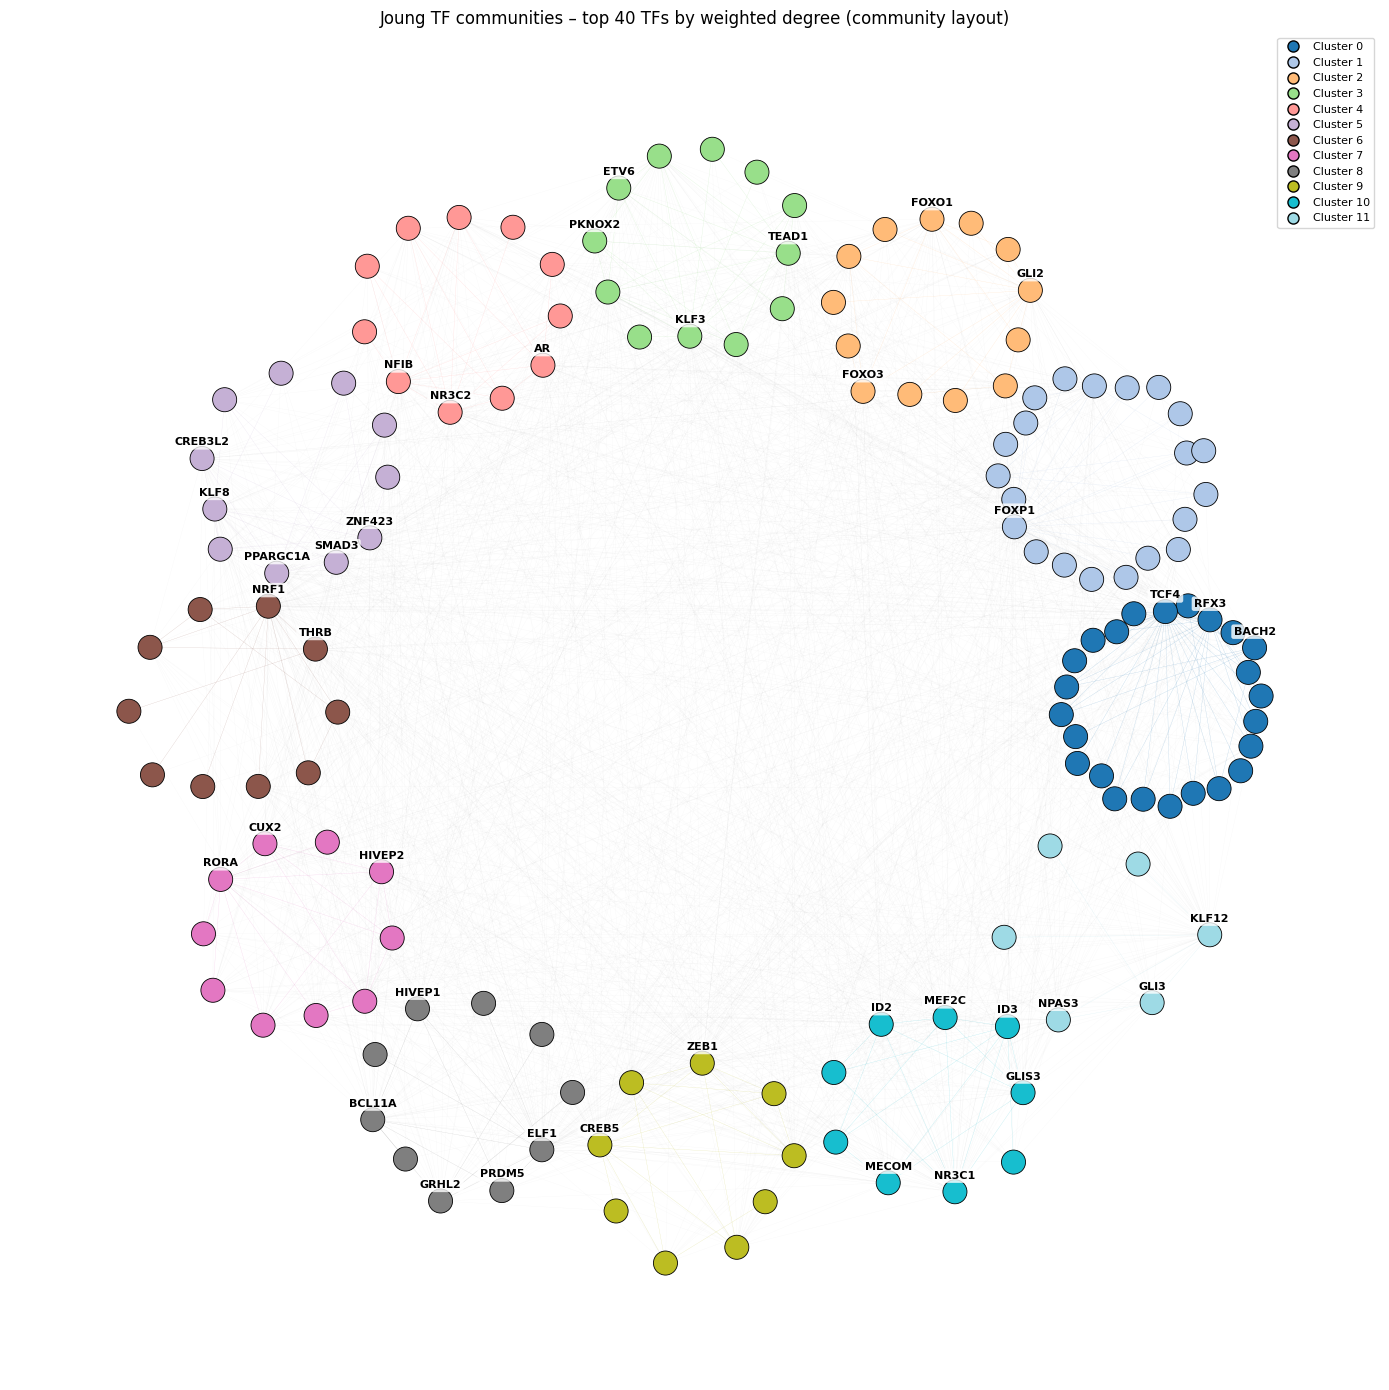

Saved: ../../../data/real/Joung2023_random_subsample/GRN/figures/tf_communities_labeled.png / .svg


In [31]:
# Labeled view: top 40 TFs by weighted degree
G_vis, pos_vis = plot_tf_tf_communities(
    current_grn=current_grn,
    tf_names=tf_names,
    consensus_labels=consensus_labels,
    layout='community',
    k=0.7,
    seed=42,
    figsize=(14, 14),
    node_size=300,
    with_labels=False,
    label_top_n_degree=40,
    edge_alpha_intra=0.35,
    edge_alpha_inter=0.08,
    edge_width_scale=2.0,
    title='Joung TF communities – top 40 TFs by weighted degree (community layout)',
    show=False,
    hide_isolates=True,
)
save_figure(plt.gcf(), 'tf_communities_labeled')


## Gene set enrichment analysis

In [32]:
# 1) Build per-cluster gene sets (TFs + targets)
cluster2genes = build_cluster_gene_sets(
    tf_names=tf_names,
    consensus_labels=consensus_labels,
    current_grn=current_grn,
)

# 2) Load GO BP gene sets (Homo sapiens)
# gseapy 1.1.11 bug: iter_lines(decode_unicode="utf-8") silently returns bytes;
# work around by decoding manually via response.text / requests directly.
_lib_name = 'GO_Biological_Process_2025'
_cache_file = os.path.join(DEFAULT_CACHE_PATH, f'Enrichr.{_lib_name}.gmt')

if os.path.isfile(_cache_file):
    raw_go_bp = {}
    with open(_cache_file) as _f:
        for _line in _f:
            _entries = _line.strip().split('\t')
            raw_go_bp[_entries[0]] = _entries[2:]
    print(f'Loaded GO library from cache: {_cache_file}')
else:
    _url = (f'http://maayanlab.cloud/Enrichr/geneSetLibrary'
            f'?mode=text&libraryName={_lib_name}')
    _resp = requests.get(_url, timeout=None, stream=True)
    if not _resp.ok:
        raise RuntimeError(f'Failed to download {_lib_name}: {_resp.status_code}')
    raw_go_bp = {}
    os.makedirs(DEFAULT_CACHE_PATH, exist_ok=True)
    with open(_cache_file, 'w') as _out:
        for _line in _resp.iter_lines(chunk_size=1024):
            if isinstance(_line, bytes):
                _line = _line.decode('utf-8')
            _parts = _line.strip().split('\t')
            _k = _parts[0]
            _v = [x.split(',')[0] for x in _parts[2:] if x.split(',')[0]]
            raw_go_bp[_k] = _v
            _out.write('\t\t'.join([_k, '\t'.join(_v)]) + '\n')
    print(f'Downloaded and cached GO library → {_cache_file}')

print(f'GO BP terms loaded: {len(raw_go_bp)}')

# 2.1) Extract GO IDs present in this library
go_ids_in_library = extract_go_ids_from_terms(raw_go_bp)

# 2.2) Compute levels only for these GO IDs (BP namespace)
# Note: go_obo_path is optional - defaults to gCRL/data/reference/ontologies/go-basic.obo
go_term_levels = compute_go_levels(
    go_ids=go_ids_in_library,
    namespace="biological_process",
)

Loaded GO library from cache: /home/laganiv/.cache/gseapy/Enrichr.GO_Biological_Process_2025.gmt
GO BP terms loaded: 5343
Loading GO DAG from /home/laganiv/Desktop/projects/CausalEmbed/grn_crl/gCAL/gCRL/data/reference/ontologies/go-basic.obo ...
/home/laganiv/Desktop/projects/CausalEmbed/grn_crl/gCAL/gCRL/data/reference/ontologies/go-basic.obo: fmt(1.2) rel(2025-10-10) 42,666 Terms


In [33]:
# 3) Filter GO BP by size and (optionally) level
go_bp_filtered = filter_gene_sets_by_size_and_level(
    gene_sets=raw_go_bp,
    min_size=20,               # min genes per GO term
    max_size=200,              # max genes per GO term
    go_term_levels=go_term_levels,
    min_level=5,               # example: only level >= 4
    max_level=None,            # or e.g. 5 if you want 4–5 only
)
len(go_bp_filtered)

1484

In [34]:
# 4) Run ORA
# universe_mode controls the background population N for the hypergeometric test:
#   'grn'    — GRN genes only (~700): biologically precise, but can be too small
#              when cluster gene-sets cover >50% of the universe (BH kills all results)
#   'custom' — arbitrary gene list via custom_universe= (recommended: pass hvg_names,
#              the 5,000 HVGs — larger than GRN, smaller than GO library,
#              and tied to the genes actually measured in this experiment)
#   'go'     — all GO library genes (~11k): maximum power but inflates
#              housekeeping terms (e.g. myeloid/erythroid differentiation in K562)
ora_results = run_ora_for_clusters(
    cluster2genes=cluster2genes,
    gene_sets=go_bp_filtered,
    universe_mode='go',
    custom_universe=hvg_names,
    min_genes_in_cluster=5,
)

print(f'Total ORA rows: {len(ora_results)}')
print(f'Rows with FDR < 0.05: {(ora_results["pval_adj"] < 0.05).sum()}')
print(f'Clusters with ≥1 significant term: {sorted(ora_results[ora_results["pval_adj"] < 0.05]["cluster_id"].unique())}')


Universe mode: 'go'  →  N = 11,748 genes
Total ORA rows: 14287
Rows with FDR < 0.05: 730
Clusters with ≥1 significant term: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]


In [35]:
# 5) Flag cell-line background terms
# Terms significantly enriched in >50% of clusters are likely housekeeping
# biology (e.g. myeloid/erythroid differentiation), not cluster-specific signal.
ora_results = filter_cluster_specific_terms(
    ora_results,
    fdr_threshold=0.05,
    max_cluster_fraction=0.5,
)

bg_terms = ora_results[ora_results['background_term']]['go_term'].unique()
print(f'Flagged background terms ({len(bg_terms)}):')
for t in sorted(bg_terms):
    print(f'  {prettify_go_term(t)}')

# Retain only cluster-specific terms for downstream analysis
filtered_ora_results = ora_results[~ora_results['background_term']].copy()

# Save results
_top_pct = int(top_percentage * 100)
_gamma = str(best_key).replace('.', 'p')
_ora_stem = f'tf_cluster_GO_BP_ORA_results_{_top_pct}pct_gamma{_gamma}'
ora_results.to_csv(results_folder + _ora_stem + '.csv', index=False)
with open(results_folder + _ora_stem + '.pkl', 'wb') as f:
    pickle.dump(ora_results, f)

filter_cluster_specific_terms: 13 clusters, FDR < 0.05, max_cluster_fraction = 0.5
  → 55 background terms flagged (significant in > 50% of clusters)
  → 13,595 rows retained
Flagged background terms (55):
  Adherens Junction Organization
  Anterograde Trans-Synaptic Signaling
  Axon Extension
  Axon Guidance
  Axonogenesis
  Calcium Ion Transmembrane Import Into Cytosol
  Cell Junction Assembly
  Cell Migration Involved in Sprouting Angiogenesis
  Central Nervous System Neuron Differentiation
  Chordate Embryonic Development
  Collagen Fibril Organization
  Embryonic Skeletal System Development
  Ephrin Receptor Signaling Pathway
  Extracellular Matrix Organization
  Generation of Neurons
  Mesenchymal Cell Migration
  Modulation of Chemical Synaptic Transmission
  Negative Regulation of Cell Migration
  Negative Regulation of Cell Motility
  Negative Regulation of G Protein-Coupled Receptor Signaling Pathway
  Negative Regulation of Sequestering of Calcium Ion
  Neural Crest Cell Dev

In [36]:
# For each cluster, show top 5 enriched GO BP terms
for cluster_id in filtered_ora_results['cluster_id'].unique():
    print(f"\nCluster {cluster_id} top GO BP terms:")
    top_terms = filtered_ora_results[filtered_ora_results['cluster_id'] == cluster_id].sort_values(by='pval').head(10)
    for _, row in top_terms.iterrows():
        print(f"  {row['go_term']} (P-value: {row['pval']:.4e}), adj p-value: {row['pval_adj']:.4e})")


Cluster 0 top GO BP terms:
  Cell-Cell Junction Organization (GO:0045216) (P-value: 1.9038e-04), adj p-value: 8.5230e-03)
  Cell-Cell Junction Assembly (GO:0007043) (P-value: 8.6276e-04), adj p-value: 2.7360e-02)
  Regulation of Cardiac Muscle Contraction by Calcium Ion Signaling (GO:0010882) (P-value: 8.6968e-04), adj p-value: 2.7360e-02)
  Sensory Perception of Light Stimulus (GO:0050953) (P-value: 1.0460e-03), adj p-value: 2.9697e-02)
  Visual Perception (GO:0007601) (P-value: 1.0460e-03), adj p-value: 2.9697e-02)
  Positive Regulation of Blood Vessel Endothelial Cell Migration (GO:0043536) (P-value: 1.2840e-03), adj p-value: 3.3212e-02)
  Negative Regulation of Cell Projection Organization (GO:0031345) (P-value: 1.4858e-03), adj p-value: 3.6797e-02)
  Regulation of Monoatomic Cation Transmembrane Transport (GO:1904062) (P-value: 2.2132e-03), adj p-value: 5.0321e-02)
  Negative Regulation of Neuron Projection Development (GO:0010977) (P-value: 2.2480e-03), adj p-value: 5.0321e-02)


### GEO enrichment dotplot

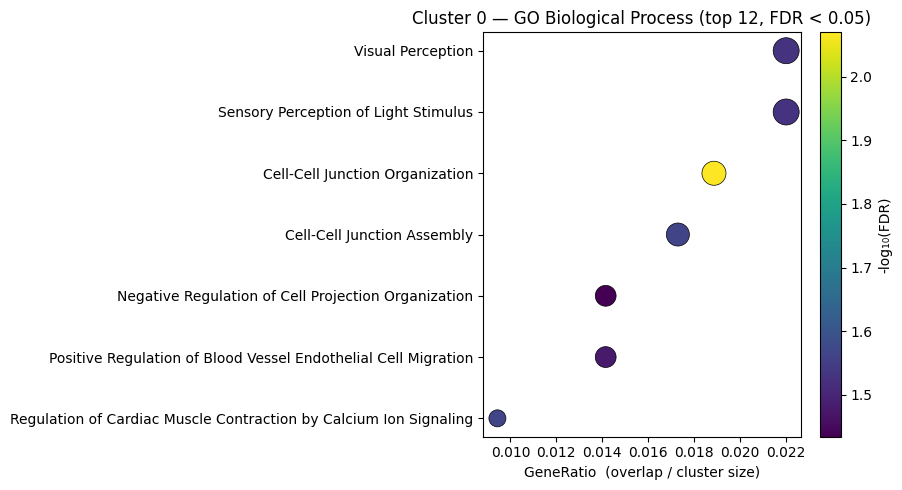

Saved: ../../../data/real/Joung2023_random_subsample/GRN/figures/dotplot_cluster_0.png / .svg


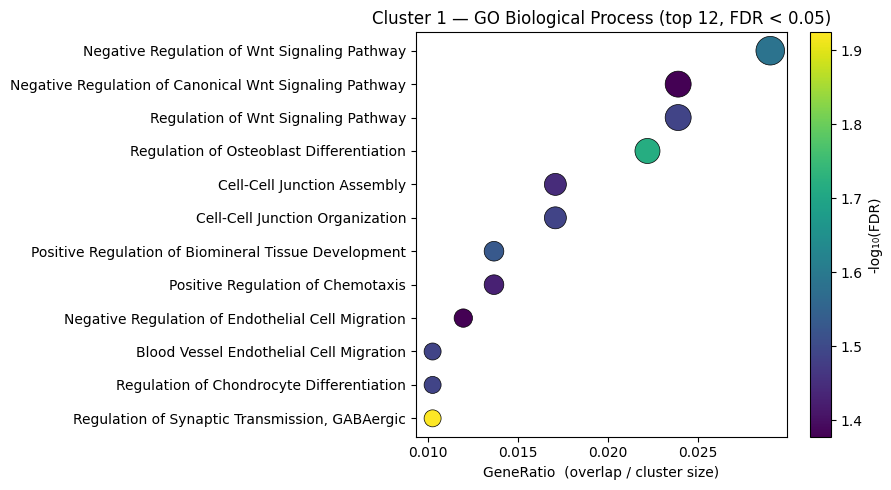

Saved: ../../../data/real/Joung2023_random_subsample/GRN/figures/dotplot_cluster_1.png / .svg


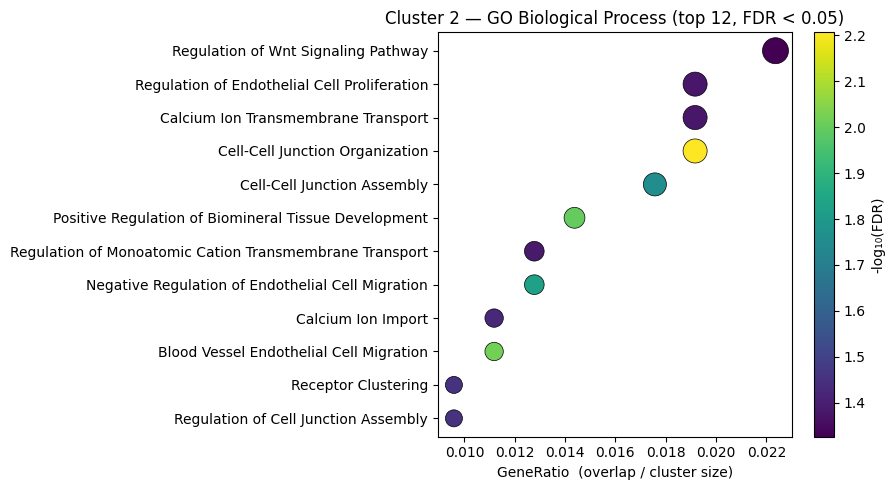

Saved: ../../../data/real/Joung2023_random_subsample/GRN/figures/dotplot_cluster_2.png / .svg


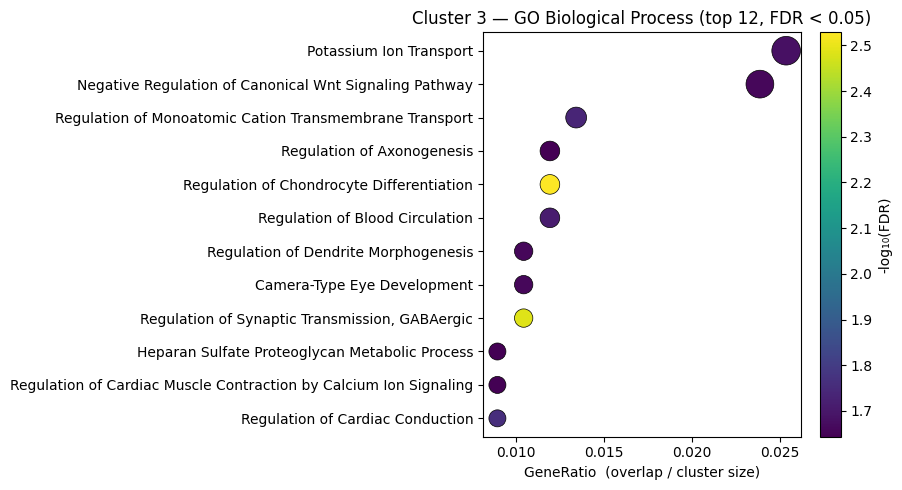

Saved: ../../../data/real/Joung2023_random_subsample/GRN/figures/dotplot_cluster_3.png / .svg


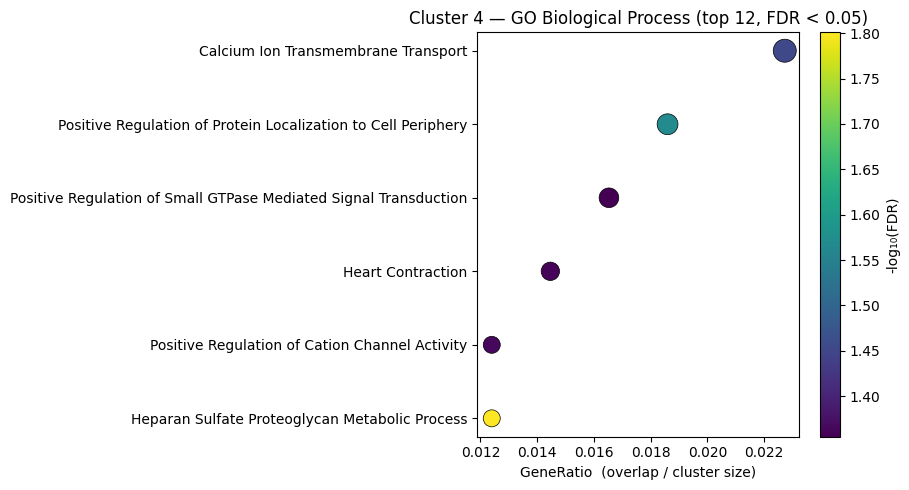

Saved: ../../../data/real/Joung2023_random_subsample/GRN/figures/dotplot_cluster_4.png / .svg


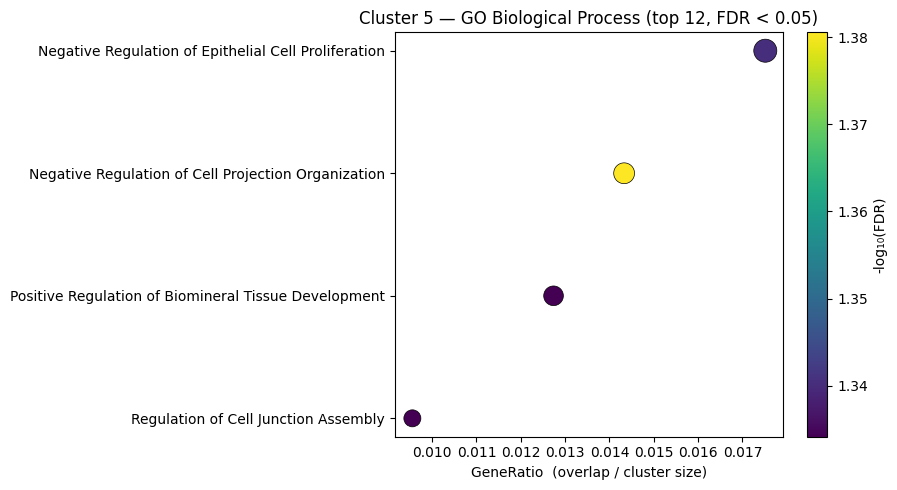

Saved: ../../../data/real/Joung2023_random_subsample/GRN/figures/dotplot_cluster_5.png / .svg


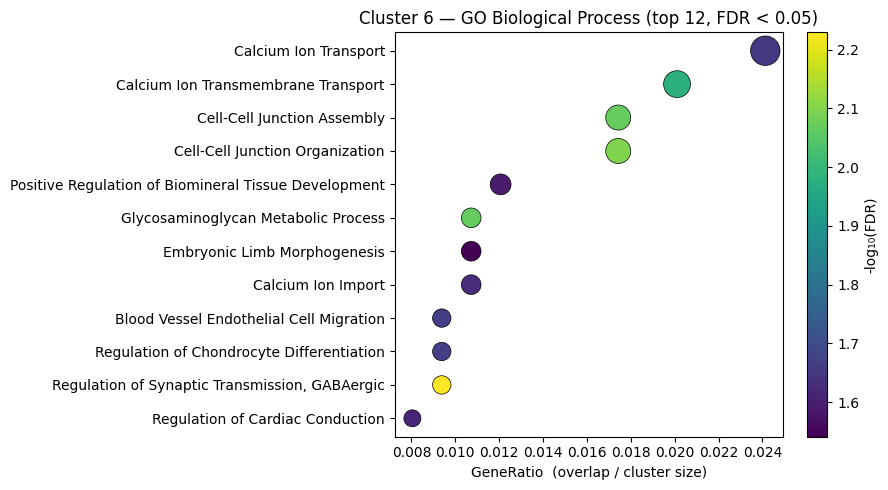

Saved: ../../../data/real/Joung2023_random_subsample/GRN/figures/dotplot_cluster_6.png / .svg


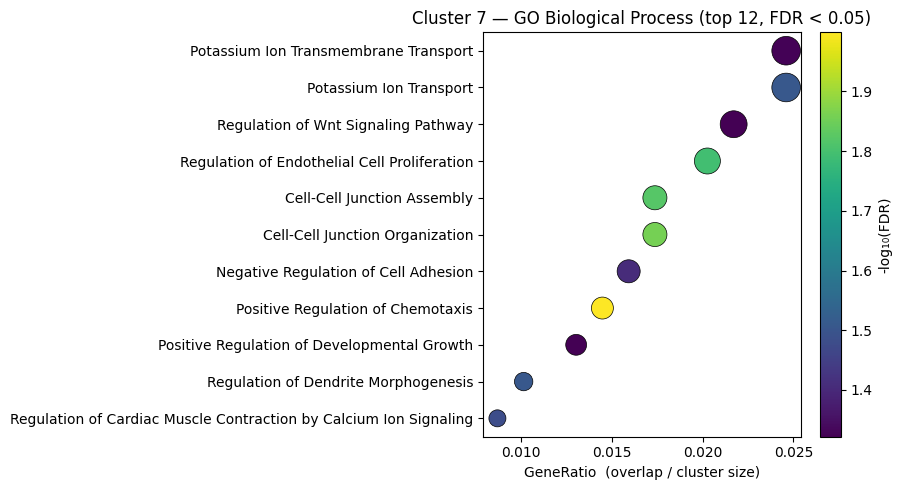

Saved: ../../../data/real/Joung2023_random_subsample/GRN/figures/dotplot_cluster_7.png / .svg


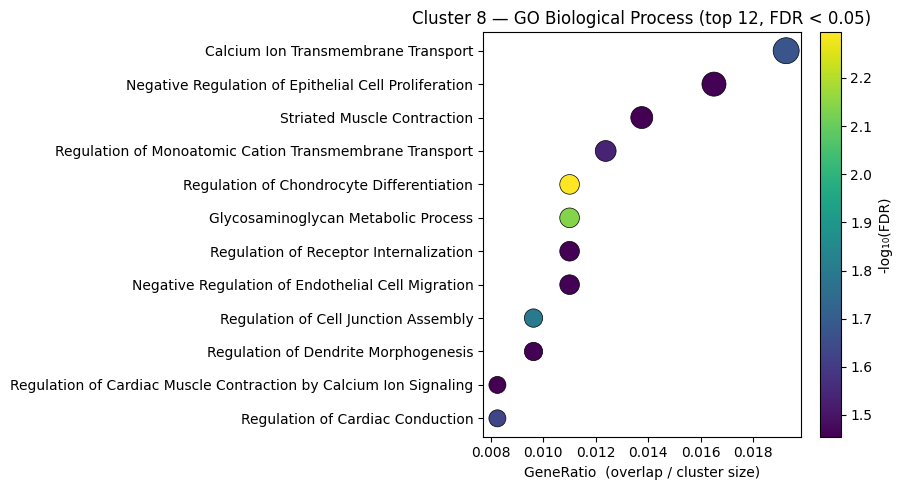

Saved: ../../../data/real/Joung2023_random_subsample/GRN/figures/dotplot_cluster_8.png / .svg


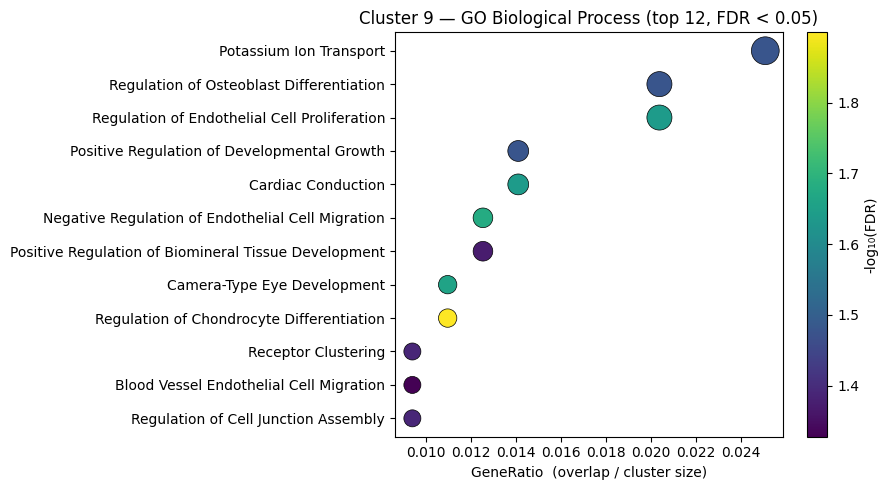

Saved: ../../../data/real/Joung2023_random_subsample/GRN/figures/dotplot_cluster_9.png / .svg


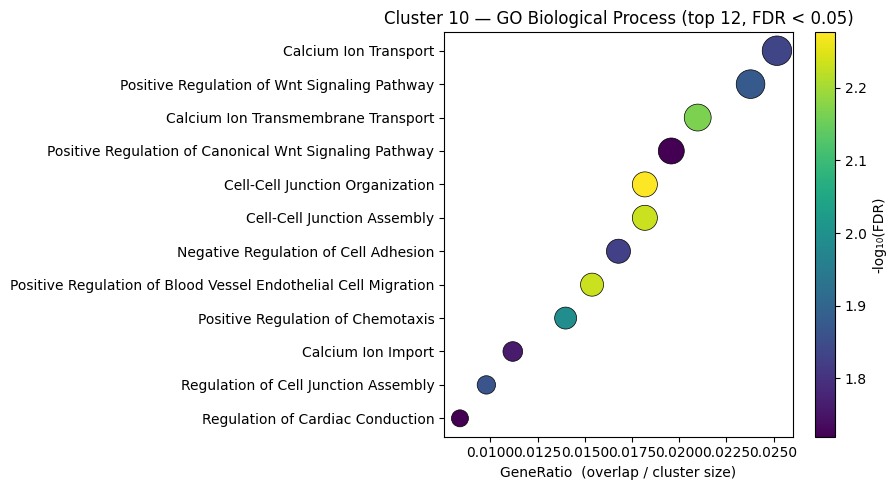

Saved: ../../../data/real/Joung2023_random_subsample/GRN/figures/dotplot_cluster_10.png / .svg


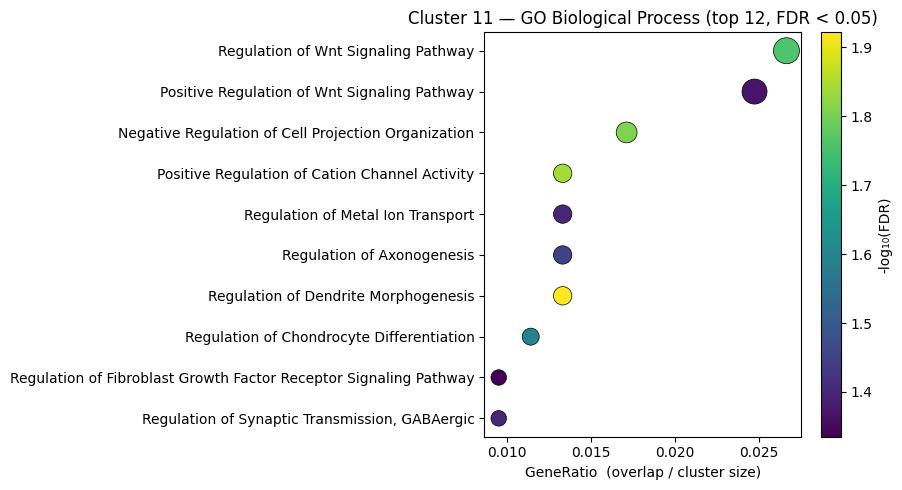

Saved: ../../../data/real/Joung2023_random_subsample/GRN/figures/dotplot_cluster_11.png / .svg


In [37]:
# One dotplot per cluster (significant, cluster-specific terms only)
sig_results = filtered_ora_results[(filtered_ora_results['pval_adj'] < 0.05)]

for cluster_id in sorted(sig_results['cluster_id'].unique()):
    n_terms = (sig_results['cluster_id'] == cluster_id).sum()
    if n_terms == 0:
        continue
    fig, ax = plot_enrichment_dotplot(
        enrich_df=sig_results,
        cluster_id=cluster_id,
        top_n=12,
        term_parser=prettify_go_term,
        figsize=(9, 5),
        title=f'Cluster {cluster_id} — GO Biological Process (top 12, FDR < 0.05)',
        show=False,
    )
    save_figure(fig, f'dotplot_cluster_{cluster_id}')
